In [15]:
!pip install -q pandas numpy matplotlib seaborn openpyxl pyarrow

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline


In [16]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
from google.colab import files
import shutil

UPLOAD_TO_DRIVE_FOLDER = "/content/drive/MyDrive/EDA_uploads"
os.makedirs(UPLOAD_TO_DRIVE_FOLDER, exist_ok=True)

uploaded = files.upload()

FILE_PATH = None
for filename in uploaded.keys():
    dest = os.path.join(UPLOAD_TO_DRIVE_FOLDER, filename)
    shutil.move(filename, dest)
    FILE_PATH = dest
    print(f"Saved to Google Drive: {dest}")


Saving dataset_A_full_leakage_free.csv to dataset_A_full_leakage_free.csv
Saved to Google Drive: /content/drive/MyDrive/EDA_uploads/dataset_A_full_leakage_free.csv


In [18]:

TARGET = None

assert FILE_PATH is not None, "Set FILE_PATH to the path of your dataset in Google Drive."

ext = os.path.splitext(FILE_PATH)[1].lower()
if ext == ".csv":
    df = pd.read_csv(FILE_PATH)
elif ext in (".xlsx", ".xls"):
    df = pd.read_excel(FILE_PATH)
elif ext == ".json":
    df = pd.read_json(FILE_PATH)
elif ext == ".parquet":
    df = pd.read_parquet(FILE_PATH)
else:
    raise ValueError(f"Unsupported file type: {ext}")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"Loaded '{os.path.basename(FILE_PATH)}' — shape: {df.shape}")
df.head()


Loaded 'dataset_A_full_leakage_free.csv' — shape: (215062, 30)


,crop,latitude,longitude,region_area,awc,bulk_density,drainage_class,tavg_mean,tavg_std,tmin_min,...,ndvi_std,fpar_mean,fpar_std,ssm_mean,ssm_std,rsm_mean,rsm_std,cal_sos,cal_eos,yield
0,maize,-9.17162,13.84699,36845.0,12.269,1.43,5.0,25.855022,1.220939,16.970,...,0.100667,52.735455,7.598911,4.749084,0.637185,237.629870,18.203678,326.833,185.622,0.60
1,maize,-9.17162,13.84699,36845.0,12.269,1.43,5.0,25.782237,1.641759,16.809,...,0.113235,48.668909,6.978770,4.792763,0.655939,240.480638,16.837890,326.833,185.622,0.75
2,maize,-9.17162,13.84699,36845.0,12.269,1.43,5.0,25.187778,1.868738,15.366,...,0.085437,54.019455,8.842269,4.749622,0.406800,236.809116,10.371054,326.833,185.622,0.50
3,maize,-9.17162,13.84699,36845.0,12.269,1.43,5.0,25.714357,1.181715,16.698,...,0.097282,48.070136,8.147855,4.325540,0.610059,226.525951,11.153656,326.833,185.622,0.34
4,maize,-9.17162,13.84699,36845.0,12.269,1.43,5.0,25.468482,1.471494,16.297,...,0.064037,61.577773,8.928502,4.954866,0.477477,243.117607,13.920375,326.833,185.622,0.30


In [19]:
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")
print("Column dtypes:")
print(df.dtypes)


Shape: 215062 rows x 30 columns
Memory usage: 58.87 MB

Column dtypes:
crop               object
latitude          float64
longitude         float64
region_area       float64
awc               float64
bulk_density      float64
drainage_class    float64
tavg_mean         float64
tavg_std          float64
tmin_min          float64
tmax_max          float64
prec_sum          float64
prec_max          float64
prec_std          float64
rad_mean          float64
rad_std           float64
et0_mean          float64
vpd_mean          float64
cwb_sum           float64
ndvi_mean         float64
ndvi_std          float64
fpar_mean         float64
fpar_std          float64
ssm_mean          float64
ssm_std           float64
rsm_mean          float64
rsm_std           float64
cal_sos           float64
cal_eos           float64
yield             float64
dtype: object


In [20]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
crop,215062,3,maize,153436,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,215062.0,NaN,NaN,NaN,3.663037,29.636808,-40.21424,-22.89882,-9.15565,37.28811,65.9623
longitude,215062.0,NaN,NaN,NaN,-46.624943,44.154306,-124.23064,-77.91572,-51.28456,-42.12244,95.60536
region_area,215062.0,NaN,NaN,NaN,2694.931076,7729.924939,20.0,382.0,1201.0,2524.0,363097.0
awc,215062.0,NaN,NaN,NaN,12.388308,2.158997,5.754,10.909,12.318,14.002,37.129
bulk_density,215062.0,NaN,NaN,NaN,1.415491,0.100803,0.556,1.336,1.422,1.497,1.794
drainage_class,215062.0,NaN,NaN,NaN,4.765356,0.715083,1.0,5.0,5.0,5.0,6.0
tavg_mean,215062.0,NaN,NaN,NaN,20.186495,4.197156,0.964848,17.324765,20.410178,23.383675,34.333842
tavg_std,215062.0,NaN,NaN,NaN,4.153212,2.354377,0.408074,2.423333,3.888152,5.196565,14.266501
tmin_min,215062.0,NaN,NaN,NaN,4.683493,9.676068,-36.499,-0.634,4.4695,11.218,24.91


In [21]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_count", ascending=False)

if missing_df.empty:
    print("No missing values found.")
else:
    display(missing_df)
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df) * 0.4)))
    sns.barplot(x=missing_df["missing_pct"], y=missing_df.index, ax=ax, color="indianred")
    ax.set_xlabel("% Missing")
    ax.set_title("Missing Values by Column")
    plt.tight_layout()
    plt.show()


No missing values found.


In [22]:
n_dupes = df.duplicated().sum()
print(f"Number of fully duplicated rows: {n_dupes} ({n_dupes / len(df) * 100:.2f}%)")


Number of fully duplicated rows: 0 (0.00%)


In [23]:
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_outliers} outliers ({n_outliers/len(df)*100:.2f}%) outside [{lower:.2f}, {upper:.2f}]")


latitude: 0 outliers (0.00%) outside [-113.18, 127.57]
longitude: 24529 outliers (11.41%) outside [-131.61, 11.57]
region_area: 22203 outliers (10.32%) outside [-2831.00, 5737.00]
awc: 1644 outliers (0.76%) outside [6.27, 18.64]
bulk_density: 895 outliers (0.42%) outside [1.09, 1.74]
drainage_class: 66947 outliers (31.13%) outside [5.00, 5.00]
tavg_mean: 479 outliers (0.22%) outside [8.24, 32.47]
tavg_std: 9140 outliers (4.25%) outside [-1.74, 9.36]
tmin_min: 4659 outliers (2.17%) outside [-18.41, 29.00]
tmax_max: 5548 outliers (2.58%) outside [26.49, 41.21]
prec_sum: 4120 outliers (1.92%) outside [-136.90, 1376.48]
prec_max: 7400 outliers (3.44%) outside [-9.83, 98.55]
prec_std: 5097 outliers (2.37%) outside [0.19, 12.84]
rad_mean: 1670 outliers (0.78%) outside [12687533.28, 23312538.09]
rad_std: 0 outliers (0.00%) outside [991156.11, 10083778.90]
et0_mean: 3625 outliers (1.69%) outside [1.92, 5.73]
vpd_mean: 7054 outliers (3.28%) outside [3.84, 29.07]
cwb_sum: 3598 outliers (1.67%) o

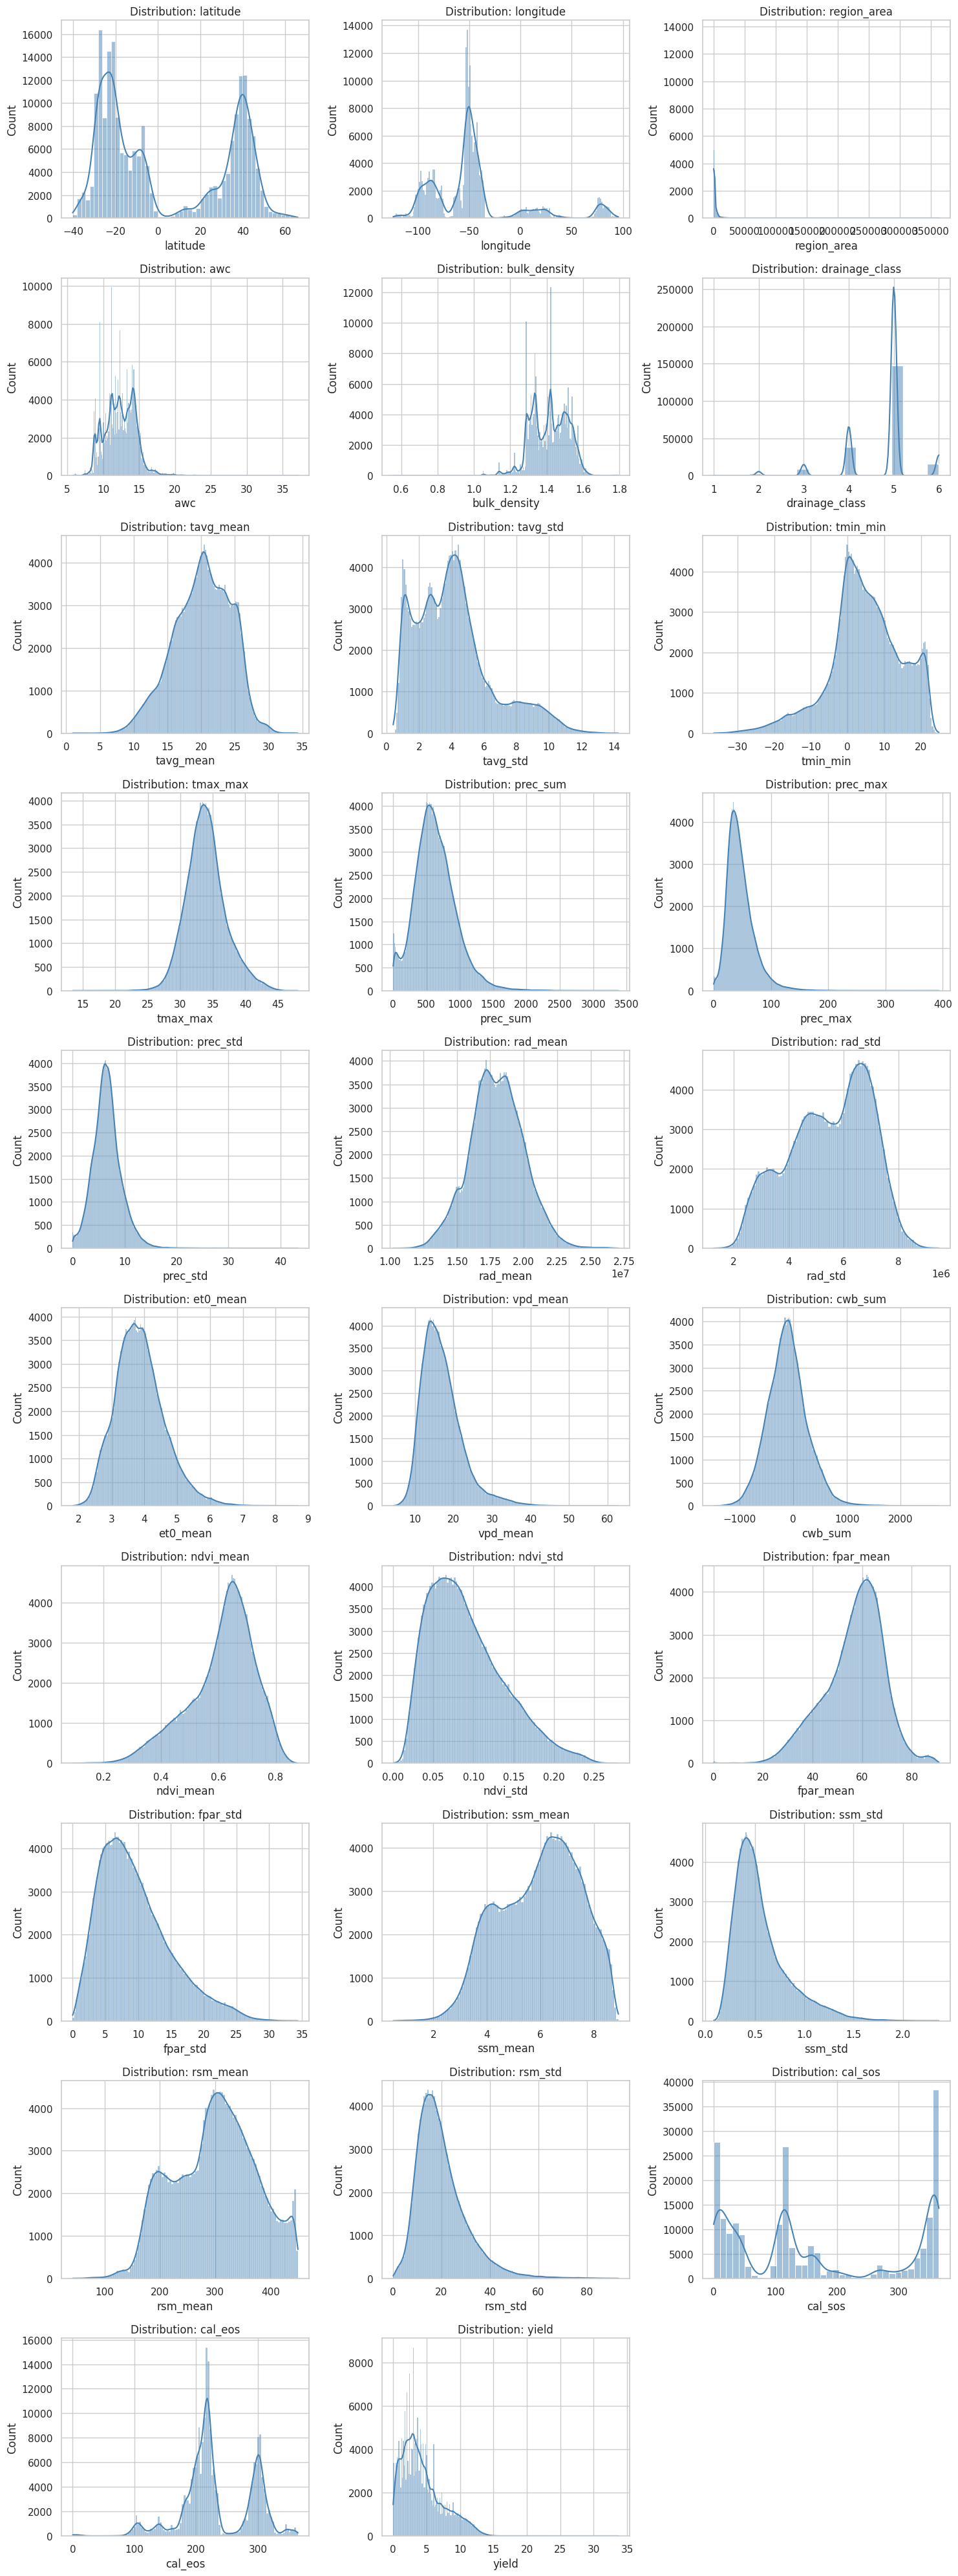

In [24]:
if numeric_cols:
    n = len(numeric_cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(numeric_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="steelblue")
        axes[i].set_title(f"Distribution: {col}")
    for j in range(i+1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns found.")


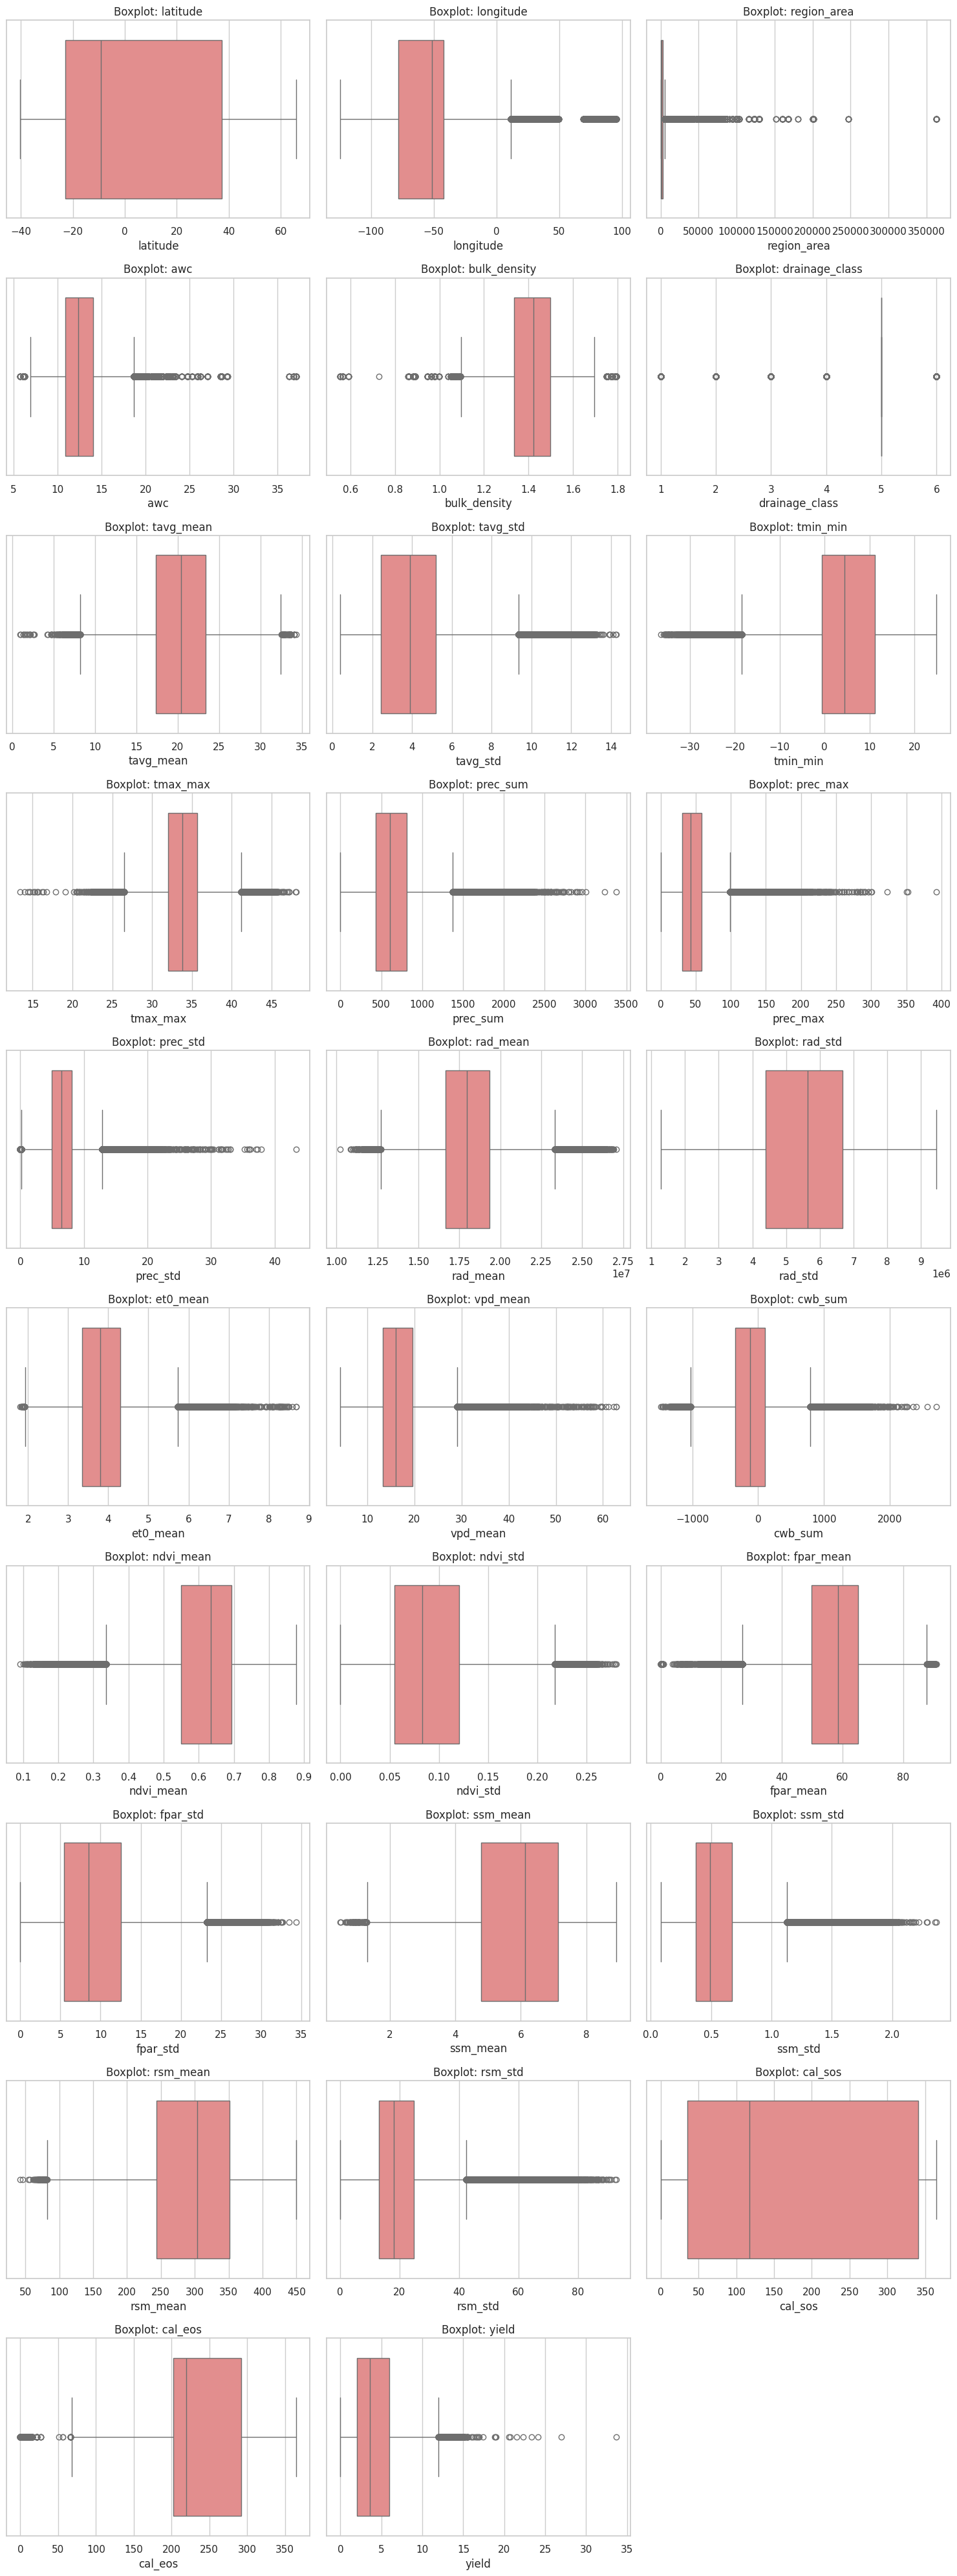

In [25]:
if numeric_cols:
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(numeric_cols):
        sns.boxplot(x=df[col], ax=axes[i], color="lightcoral")
        axes[i].set_title(f"Boxplot: {col}")
    for j in range(i+1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()


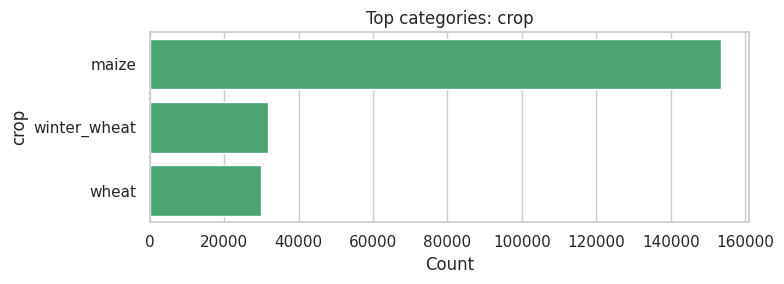

In [26]:
for col in categorical_cols:
    n_unique = df[col].nunique()
    if n_unique > 50:
        print(f"Skipping '{col}' (too many unique values: {n_unique})")
        continue
    counts = df[col].value_counts().head(10)
    fig, ax = plt.subplots(figsize=(8, max(3, len(counts) * 0.4)))
    sns.barplot(x=counts.values, y=counts.index, ax=ax, color="mediumseagreen")
    ax.set_xlabel("Count")
    ax.set_title(f"Top categories: {col}")
    plt.tight_layout()
    plt.show()


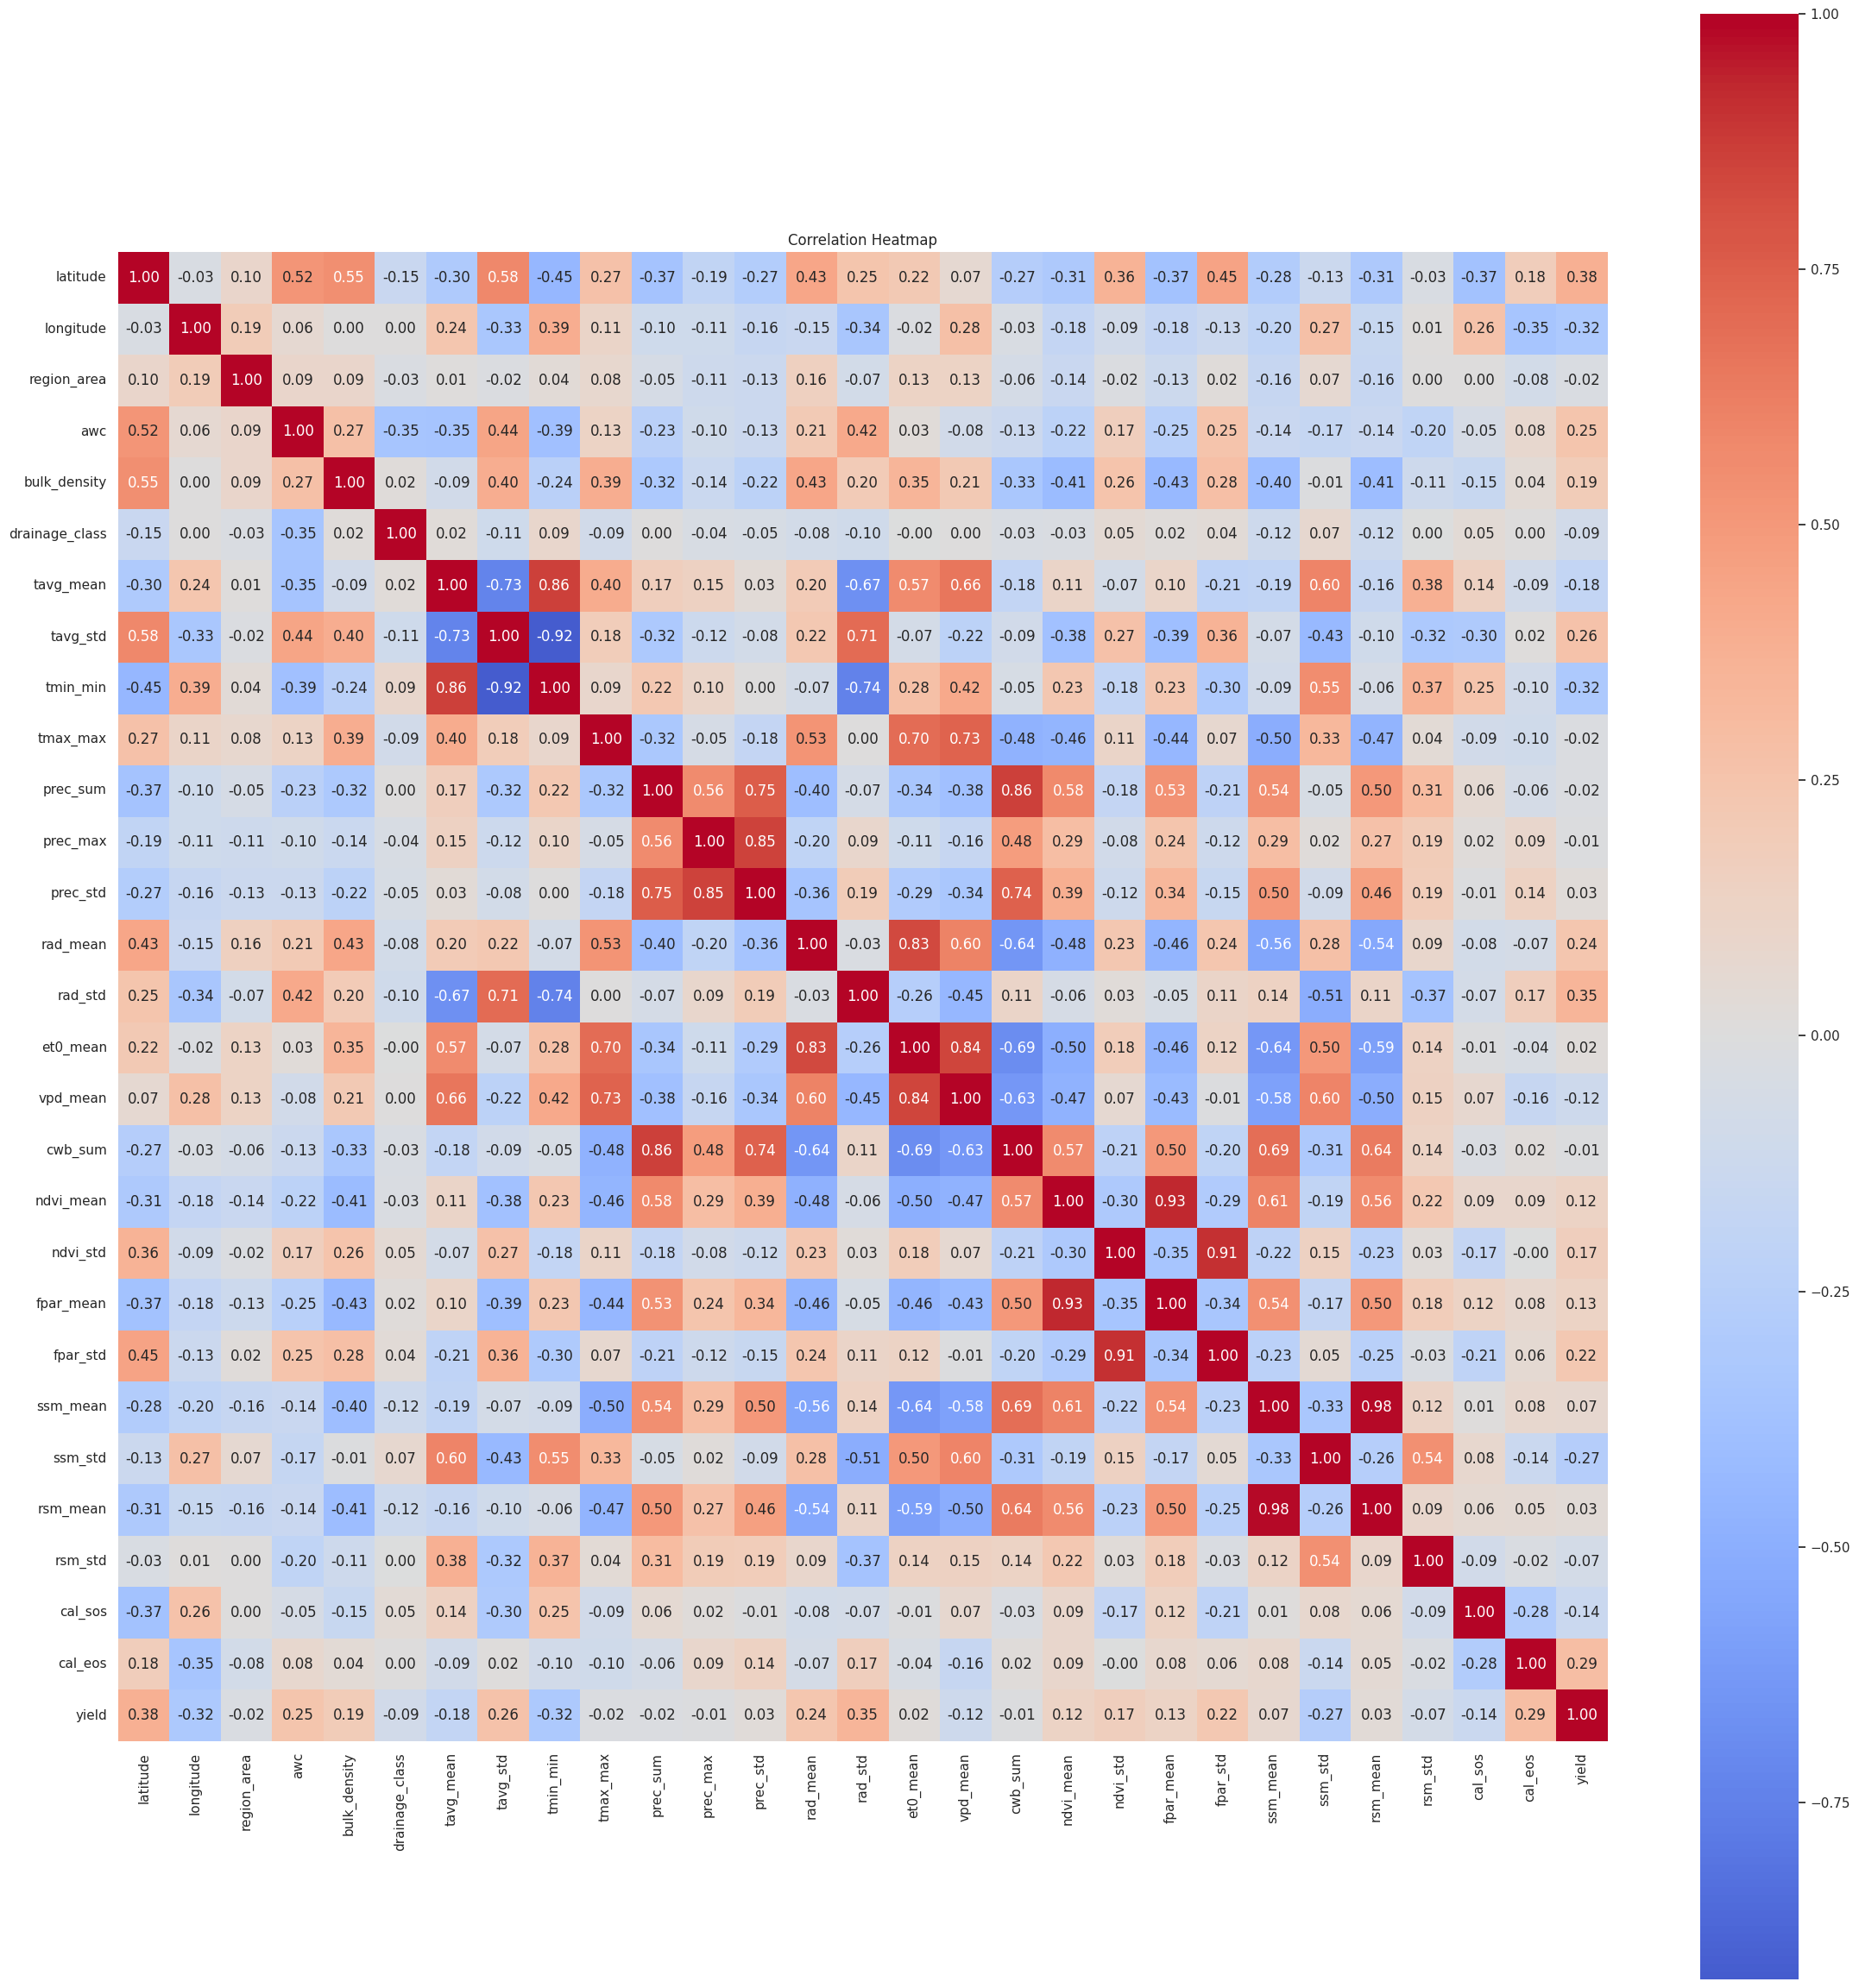


Strong correlations (|r| > 0.7):
  ssm_mean <-> rsm_mean: 0.981
  ndvi_mean <-> fpar_mean: 0.93
  tavg_std <-> tmin_min: -0.923
  ndvi_std <-> fpar_std: 0.905
  tavg_mean <-> tmin_min: 0.863
  prec_sum <-> cwb_sum: 0.859
  prec_max <-> prec_std: 0.851
  et0_mean <-> vpd_mean: 0.844
  rad_mean <-> et0_mean: 0.831
  prec_sum <-> prec_std: 0.753
  prec_std <-> cwb_sum: 0.738
  tmin_min <-> rad_std: -0.736
  tavg_mean <-> tavg_std: -0.733
  tmax_max <-> vpd_mean: 0.733
  tavg_std <-> rad_std: 0.707


In [27]:
if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr()
    fig, ax = plt.subplots(figsize=(max(6, len(numeric_cols)*0.8), max(5, len(numeric_cols)*0.8)))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
    ax.set_title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

    print("\nStrong correlations (|r| > 0.7):")
    strong = []
    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            r = corr.iloc[i, j]
            if abs(r) > 0.7:
                strong.append((corr.columns[i], corr.columns[j], round(r, 3)))
    if strong:
        for a, b, r in sorted(strong, key=lambda x: -abs(x[2])):
            print(f"  {a} <-> {b}: {r}")
    else:
        print("  None found.")
else:
    print("Not enough numeric columns for correlation analysis.")


In [28]:
if TARGET and TARGET in df.columns:
    if TARGET in numeric_cols:
        display(df[TARGET].describe())
        other_numeric = [c for c in numeric_cols if c != TARGET]
        if other_numeric:
            corrs = df[other_numeric].corrwith(df[TARGET]).sort_values(key=abs, ascending=False)
            print("\nCorrelation with target:")
            print(corrs.round(3))
    else:
        display(df[TARGET].value_counts())
        fig, ax = plt.subplots(figsize=(7, 4))
        sns.countplot(x=df[TARGET], ax=ax, order=df[TARGET].value_counts().index)
        ax.set_title(f"Target distribution: {TARGET}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

        for col in numeric_cols[:6]:
            fig, ax = plt.subplots(figsize=(7, 4))
            sns.boxplot(x=df[TARGET], y=df[col], ax=ax)
            ax.set_title(f"{col} by {TARGET}")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()
else:
    print("No TARGET set — skipping target analysis. (Set TARGET in section 4 to enable this.)")


No TARGET set — skipping target analysis. (Set TARGET in section 4 to enable this.)
